<a href="https://colab.research.google.com/github/suryamanoj4/SMAI-A1/blob/main/SMAI_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dependencies

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
from scipy.spatial.distance import cosine, cdist # Import cdist for more efficient cosine distance

# 1. Automated Essay Scoring System

Automate Essay Scoring(AES) system using handcrafted statistical features and K-Nearest-Neighbors (KNN) algorithm.

In [2]:
class EssayFeatureExtractor:

    def __init__(self):
        # Common abbreviations that contain periods which are from checking the given essays and other commonly used abrevations
        # and should NOT be treated as sentence boundaries
        self.abbreviations = {
            "mr.", "mrs.", "ms.", "dr.", "prof.", "sr.", "jr.",
            "st.", "vs.", "etc.", "e.g.", "i.e.",
            "a.m.", "p.m.",
            "fig.", "no.",
            "inc.",
            "jan.", "feb.", "mar.", "apr.", "jun.",
            "jul.", "aug.", "sep.", "sept.", "oct.",
            "nov.", "dec."
        }

    def _clean_text(self, text):
        """Basic text cleaning """
        text = str(text)
        # Replace multiple spaces/newlines/tabs with a single space
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    def _split_sentences(self, text):
        """
        Split essay into sentences while protecting:
        - Common abbreviations
        - Initials
        - Decimal numbers

        Example:
        'Dr. Surya is here. He is a teacher.'
        ->
        ['Dr. Surya is here.', 'He is a teacher.']
        """

        text = self._clean_text(text)
        protected_text = text
        for abbreviation in self.abbreviations:
            # Escape the abbreviation so periods are treated literally
            pattern = re.escape(abbreviation)
            protected_text = re.sub(
                pattern,
                abbreviation.replace('.', '<DOT>'),
                protected_text,
                flags=re.IGNORECASE
            )
        #protect initials
        protected_text = re.sub(
            r'\b([A-Za-z])\.',
            r'\1<DOT>',
            protected_text
        )
        #protect decimal numbers
        protected_text = re.sub(
            r'(?<=\d)\.(?=\d)',
            '<DOT>',
            protected_text
        )
        #split sentences
        sentences = re.split(
            r'(?<=[.!?])\s+(?=[A-Z0-9"\'])',
            protected_text
        )
        # Restore protected periods
        sentences = [
            sentence.replace('<DOT>', '.').strip()
            for sentence in sentences
            if sentence.strip()
        ]
        return sentences

    def _tokenize_words(self, text):
        """
        Simple statistical word tokenization.
        """

        return re.findall(
            r"\b[A-Za-z]+(?:'[A-Za-z]+)?\b",
            text.lower()
        )

    def extract_features(self, essay):
        """Extract statistical features from an essay."""

        essay = self._clean_text(essay)
        sentences = self._split_sentences(essay)
        words = self._tokenize_words(essay)
        word_count = len(words)
        sentence_count = len(sentences)
        short_words = sum(
            len(word) < 4
            for word in words
        )
        medium_words = sum(
            4 <= len(word) <= 10
            for word in words
        )
        long_words = sum(
            len(word) > 10
            for word in words
        )
        unique_words = len(set(words))
        sentence_word_counts = [
            len(self._tokenize_words(sentence))
            for sentence in sentences
        ]
        short_sentences = sum(
            count < 4
            for count in sentence_word_counts
        )
        medium_sentences = sum(
            4 <= count <= 10
            for count in sentence_word_counts
        )
        long_sentences = sum(
            count > 10
            for count in sentence_word_counts
        )
        word_density = (
            word_count / sentence_count
            if sentence_count > 0
            else 0
        )
        word_frequency = Counter(words)
        repeat_frequency = sum(
            count - 1
            for count in word_frequency.values()
            if count > 1
        )

        features = {
            'word_count': word_count,
            'sentence_count': sentence_count,
            'short_words': short_words,
            'medium_words': medium_words,
            'long_words': long_words,
            'unique_words': unique_words,
            'short_sentences': short_sentences,
            'medium_sentences': medium_sentences,
            'long_sentences': long_sentences,
            'word_density': word_density,
            'repeat_frequency': repeat_frequency
        }

        return features

In [3]:
class Dataset:
  def __init__(self, path):
    self.path = path
    self.df = pd.read_csv(path)
    self.feature_means = None
    self.feature_stds = None

  def feature_extraction(self):
    extractor = EssayFeatureExtractor()
    feature_df = self.df["full_text"].apply(extractor.extract_features).apply(pd.Series)
    normalized_feature_df = self.feature_normalization(feature_df, store_params=True)
    self.df = pd.concat([self.df, normalized_feature_df], axis=1)
    return self.df

  def feature_normalization(self, df, stored_mean=None, stored_std=None, store_params=False):
    """Normalize features to same scale: using Z-score standardization.
    Optionally use stored mean and std for normalization, or store them if store_params is True."""
    if stored_mean is None or stored_std is None:
        # Calculate mean and std from the provided df (presumably training data)
        if store_params:
            self.feature_means = df.mean()
            self.feature_stds = df.std()
        normalized_df = (df - df.mean()) / df.std()
    else:
        # Use stored mean and std for normalization (for new data)
        normalized_df = (df - stored_mean) / stored_std
    return normalized_df

  def train_val_test_split(self, feature_columns, target_column, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=None):
    if not (train_ratio + val_ratio + test_ratio == 1.0):
        raise ValueError("Train, validation, and test ratios must sum to 1.0")

    if random_state is not None:
        # For reproducibility, if a random_state is provided
        np.random.seed(random_state)

    # Shuffle the DataFrame
    shuffled_df = self.df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Separate features (X) and target (y)
    X = shuffled_df[feature_columns]
    y = shuffled_df[target_column]

    total_samples = len(shuffled_df)
    train_end = int(train_ratio * total_samples)
    val_end = train_end + int(val_ratio * total_samples)

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_val = X.iloc[train_end:val_end]
    y_val = y.iloc[train_end:val_end]

    X_test = X.iloc[val_end:]
    y_test = y.iloc[val_end:]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [4]:
dataset = Dataset("/content/essays(in).csv")
df = dataset.feature_extraction()
df.head()

,essay_id,full_text,score,word_count,sentence_count,short_words,medium_words,long_words,unique_words,short_sentences,medium_sentences,long_sentences,word_density,repeat_frequency
0,000d118,Many people have car where they live. The thin...,3,0.874923,-0.122038,1.005260,0.727886,0.966050,1.016656,-0.214913,0.015307,-0.139581,-0.039198,0.745081
1,000fe60,I am a scientist at NASA that is discussing th...,3,-0.232360,0.266051,0.054289,-0.385501,-0.872507,-0.399852,-0.214913,0.015307,0.332303,-0.339599,-0.130127
2,001ab80,People always wish they had the same technolog...,4,1.228453,0.912866,1.327623,1.080079,1.374619,1.128486,-0.214913,-0.381269,1.276073,-0.245701,1.202134
3,001bdc0,"We all heard about Venus, the planet without a...",4,0.534734,0.136688,0.312179,0.625636,1.170335,0.867550,-0.214913,-0.381269,0.332303,-0.184759,0.326926
4,002ba53,"Dear, State SenatorThis is a letter to argue i...",3,0.047796,-0.510127,0.247707,-0.158279,1.170335,-0.530320,-0.214913,-0.777846,-0.296876,-0.054728,0.346375


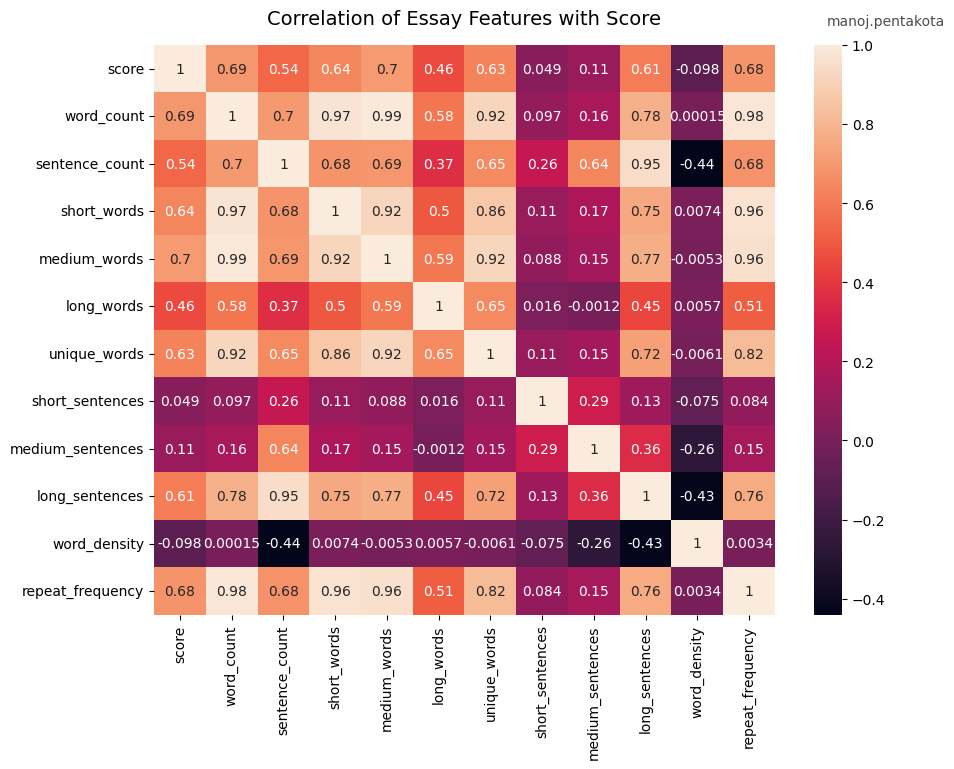

In [5]:
#confusion matrix for correlation between score and features

feature_cols = [
    'score', 'word_count', 'sentence_count', 'short_words',
    'medium_words', 'long_words', 'unique_words',
    'short_sentences', 'medium_sentences', 'long_sentences',
    'word_density', 'repeat_frequency'
]

corr_matrix = df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation of Essay Features with Score', fontsize=14, pad=15)
plt.text(0.95, 0.95, "manoj.pentakota",ha='right',va='top',transform=plt.gcf().transFigure, fontsize=10,alpha=0.7)
plt.show
plt.tight_layout()
plt.show()

/tmp/ipykernel_3255/1330114330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='score', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3255/1330114330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='score', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3255/1330114330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='score', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3255/1330114330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

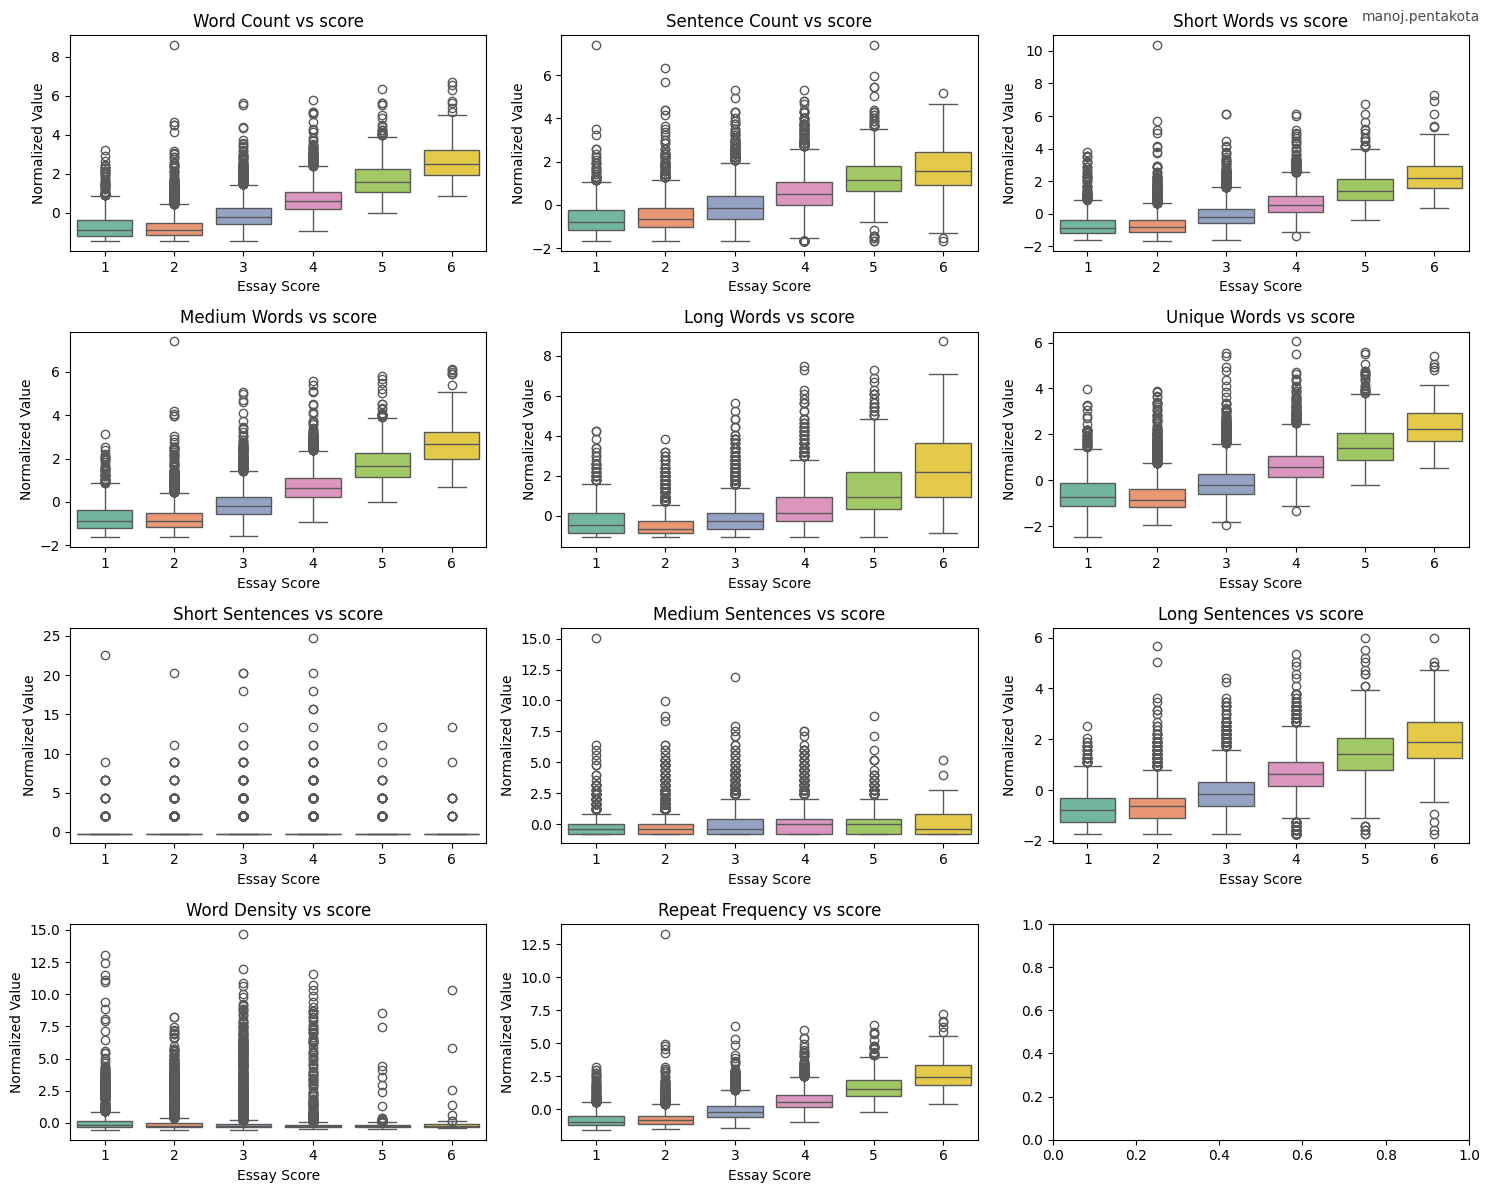

In [6]:
# box plots for per feature to score relation

features_to_plot = [col for col in feature_cols  if col!= "score"]
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i,col in enumerate(features_to_plot):
    sns.boxplot(x='score', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col.replace("_", " ").title()} vs score')
    axes[i].set_xlabel('Essay Score')
    axes[i].set_ylabel('Normalized Value')

fig.text(0.99, 0.99, "manoj.pentakota",ha='right',va='top',transform=plt.gcf().transFigure, fontsize=10,alpha=0.7)

plt.tight_layout()
plt.show()


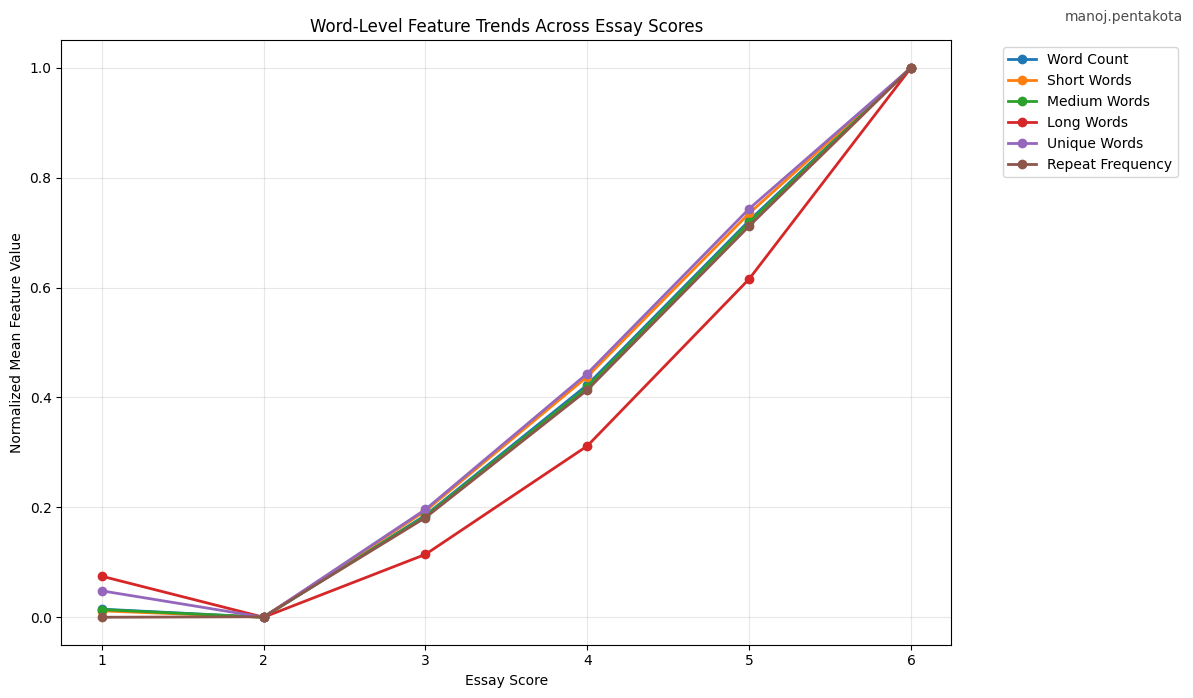

In [7]:
# word level features trends across score range

word_features = [
    'word_count',
    'short_words',
    'medium_words',
    'long_words',
    'unique_words',
    'repeat_frequency'
]
plt.figure(figsize=(12, 7))
for feature in word_features:
    mean_values = df.groupby('score')[feature].mean()
    # Normalize so features with different scales can be compared
    mean_values = (
        mean_values - mean_values.min()
    ) / (
        mean_values.max() - mean_values.min()
    )
    plt.plot(
        mean_values.index,
        mean_values.values,
        marker='o',
        linewidth=2,
        label=feature.replace('_', ' ').title()
    )
plt.title('Word-Level Feature Trends Across Essay Scores')
plt.xlabel('Essay Score')
plt.ylabel('Normalized Mean Feature Value')
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.grid(alpha=0.3)
plt.figtext(
    0.99, 0.99,
    "manoj.pentakota",
    ha='right',
    va='top',
    fontsize=10,
    alpha=0.7
)
plt.tight_layout()
plt.show()

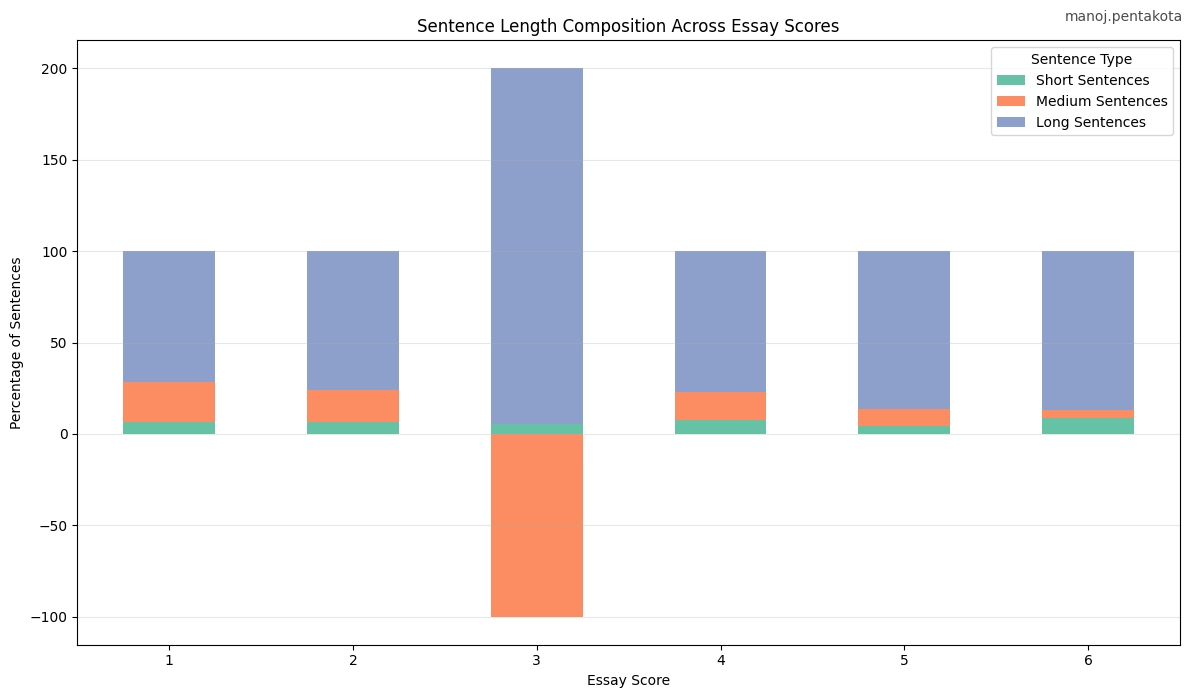

In [8]:
#sentence lenth percentages across scores

sentence_features = [
    'short_sentences',
    'medium_sentences',
    'long_sentences'
]
sentence_counts = df.groupby('score')[sentence_features].mean()
# Convert counts into proportions
sentence_proportions = (
    sentence_counts.div(
        sentence_counts.sum(axis=1),
        axis=0
    ) * 100
)
ax = sentence_proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    color=['#66c2a5', '#fc8d62', '#8da0cb']
)
plt.title('Sentence Length Composition Across Essay Scores')
plt.xlabel('Essay Score')
plt.ylabel('Percentage of Sentences')
plt.legend(
    title='Sentence Type',
    labels=[
        'Short Sentences',
        'Medium Sentences',
        'Long Sentences'
    ]
)
plt.xticks(rotation=0)
plt.grid(
    axis='y',
    alpha=0.3
)
plt.figtext(
    0.99, 0.99,
    "manoj.pentakota",
    ha='right',
    va='top',
    fontsize=10,
    alpha=0.7
)
plt.tight_layout()
plt.show()

In [9]:
class KNN:
  def __init__(self, k=5, distance='euclidean'):
    self.k = k
    self.distance = distance
    self.X_train = None
    self.y_train = None

  def fit(self, X_train, y_train):
    """store the training feature vectors and scores"""
    # convert inputs to numpy arrays for fast vector math
    self.X_train = np.array(X_train)
    self.y_train = np.array(y_train)

  def _compute_distance(self, x):
    """calculate distance between given point and all training points """
    # Ensure inputs are float for distance calculations
    x = np.asarray(x, dtype=float)
    X_train_float = np.asarray(self.X_train, dtype=float)

    if self.distance == 'euclidean':
      return np.sqrt(np.sum((X_train_float - x)**2, axis=1))
    elif self.distance == 'manhattan':
      return np.sum(np.abs(X_train_float - x), axis=1)
    elif self.distance == 'cosine':
      # cdist computes distances between each pair of the two collections of inputs.
      # We want distance between a single point x and all points in X_train.
      # x needs to be reshaped to (1, n_features) for cdist.
      return cdist(x.reshape(1, -1), X_train_float, metric='cosine')[0]
    else:
      raise ValueError(f"Invalid distance metric: '{self.distance}'. Supported: 'euclidean', 'manhattan', 'cosine'")

  def predict(self, X_test):
    """predict essay scores for given feature vector"""
    X_test = np.array(X_test)
    return np.array([self._predict_single(x) for x in X_test])

  def _predict_single(self, x):
    """helper to predict for single point"""
    distances = self._compute_distance(x)
    k_indices = np.argsort(distances)[:self.k]
    k_nearest_distances = distances[k_indices]
    k_nearest_labels = self.y_train[k_indices]

    # Give closer neighbours bore influence
    weights = 1/ (k_nearest_distances  + 1e-8)

    weighted_predictions = np.sum(weights * k_nearest_labels)/np.sum(weights)
    # Round final prefiction to integer
    return int(np.round(weighted_predictions))

In [10]:
class Evaluation:
    def __init__(self):
        pass

    def calculate_mae(self, y_true, y_pred):
        """Calculates Mean Absolute Error (MAE)."""
        return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

    def calculate_rmse(self, y_true, y_pred):
        """Calculates Root Mean Squared Error (RMSE)."""
        return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))

    def calculate_r2_score(self, y_true, y_pred):
        """Calculates R-squared (R2) score."""
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        ss_total = np.sum((y_true - np.mean(y_true))**2)
        ss_residual = np.sum((y_true - y_pred)**2)
        # Avoid division by zero if ss_total is zero (all true values are identical)
        if ss_total == 0:
            return 1.0 if ss_residual == 0 else 0.0 # Perfect fit if residuals are also zero
        return 1 - (ss_residual / ss_total)

    def calculate_pearson_correlation(self, y_true, y_pred):
        """Calculates Pearson Correlation Coefficient."""
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        mean_y_true = np.mean(y_true)
        mean_y_pred = np.mean(y_pred)
        numerator = np.sum((y_true - mean_y_true) * (y_pred - mean_y_pred))
        denominator = np.sqrt(np.sum((y_true - mean_y_true)**2) * np.sum((y_pred - mean_y_pred)**2))
        # Avoid division by zero
        if denominator == 0:
            return 0.0
        return numerator / denominator


In [11]:
import hashlib
username = "manoj.pentakota" # You can replace this with a dynamic username if available
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

In [12]:
# Define the feature columns and target column
feature_cols_for_model = [
    'word_count', 'sentence_count', 'short_words',
    'medium_words', 'long_words', 'unique_words',
    'short_sentences', 'medium_sentences', 'long_sentences',
    'word_density', 'repeat_frequency'
]
target_col = 'score'

# Perform the custom train, validation, and test split
X_train, y_train, X_val, y_val, X_test, y_test = dataset.train_val_test_split(
    feature_columns=feature_cols_for_model,
    target_column=target_col,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=seed # for reproducibility
)

print(f"Training set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 12114 samples
Validation set size: 2596 samples
Test set size: 2597 samples


In [13]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
distance_metrics = ['euclidean', 'manhattan', 'cosine']

# Initialize the Evaluation class
evaluator = Evaluation()

results = []

for k in k_values:
    for dist_metric in distance_metrics:
        print(f"Testing K={k}, Distance='{dist_metric}'...")

        # Initialize and fit the KNN model
        knn_model = KNN(k=k, distance=dist_metric)
        knn_model.fit(X_train, y_train)

        # Make predictions on the validation set
        y_pred_val = knn_model.predict(X_val)

        # Calculate evaluation metrics
        mae = evaluator.calculate_mae(y_val, y_pred_val)
        rmse = evaluator.calculate_rmse(y_val, y_pred_val)
        r2 = evaluator.calculate_r2_score(y_val, y_pred_val)
        pearson_corr = evaluator.calculate_pearson_correlation(y_val, y_pred_val)

        # Store results
        results.append({
            'K': k,
            'Distance': dist_metric,
            'MAE': mae,
            'RMSE': rmse,
            'R2 Score': r2,
            'Pearson Correlation': pearson_corr
        })
# Convert results to a DataFrame for better readability
results_df = pd.DataFrame(results)

# Sort by MAE (lower is better) to easily find the best models
results_df_sorted = results_df.sort_values(by='MAE').reset_index(drop=True)
display(results_df_sorted)

Testing K=1, Distance='euclidean'...
Testing K=1, Distance='manhattan'...
Testing K=1, Distance='cosine'...
Testing K=3, Distance='euclidean'...
Testing K=3, Distance='manhattan'...
Testing K=3, Distance='cosine'...
Testing K=5, Distance='euclidean'...
Testing K=5, Distance='manhattan'...
Testing K=5, Distance='cosine'...
Testing K=7, Distance='euclidean'...
Testing K=7, Distance='manhattan'...
Testing K=7, Distance='cosine'...
Testing K=9, Distance='euclidean'...
Testing K=9, Distance='manhattan'...
Testing K=9, Distance='cosine'...
Testing K=11, Distance='euclidean'...
Testing K=11, Distance='manhattan'...
Testing K=11, Distance='cosine'...
Testing K=15, Distance='euclidean'...
Testing K=15, Distance='manhattan'...
Testing K=15, Distance='cosine'...
Testing K=21, Distance='euclidean'...
Testing K=21, Distance='manhattan'...
Testing K=21, Distance='cosine'...


,K,Distance,MAE,RMSE,R2 Score,Pearson Correlation
0,21,manhattan,0.504237,0.779900,0.457341,0.685359
1,21,euclidean,0.504622,0.780640,0.456310,0.683476
2,15,manhattan,0.508860,0.784823,0.450467,0.681987
3,11,euclidean,0.515794,0.791178,0.441532,0.676319
4,11,manhattan,0.516564,0.791665,0.440845,0.676957
5,15,euclidean,0.517334,0.790691,0.442219,0.675654
6,9,euclidean,0.520031,0.795306,0.435689,0.674108
7,21,cosine,0.523112,0.797724,0.432253,0.675312
8,11,cosine,0.523883,0.798207,0.431565,0.677824
9,15,cosine,0.524268,0.797483,0.432596,0.676473


In [14]:
# Get the best hyperparameters from the tuning results
best_params = results_df_sorted.iloc[0]
best_k = int(best_params['K'])
best_distance = best_params['Distance']

print(f"\nBest K: {best_k}, Best Distance: '{best_distance}'")

# Initialize and fit the KNN model with the best hyperparameters on the training data
best_knn_model = KNN(k=best_k, distance=best_distance)
best_knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test = best_knn_model.predict(X_test)

# Initialize the Evaluation class
evaluator = Evaluation()

# Calculate evaluation metrics for the test set
mae_test = evaluator.calculate_mae(y_test, y_pred_test)
rmse_test = evaluator.calculate_rmse(y_test, y_pred_test)
r2_test = evaluator.calculate_r2_score(y_test, y_pred_test)
pearson_corr_test = evaluator.calculate_pearson_correlation(y_test, y_pred_test)

print("\n--- Final Evaluation on Test Set ---")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"R2 Score: {r2_test:.4f}")
print(f"Pearson Correlation Coefficient: {pearson_corr_test:.4f}")

# Display first 5 predictions on test data (optional, but good for quick check)
print("\nFirst 5 predictions on test data:")
print(y_pred_test[:5])
print("First 5 actual labels from test data:")
print(y_test[:5].values)


Best K: 21, Best Distance: 'manhattan'

--- Final Evaluation on Test Set ---
Mean Absolute Error (MAE): 0.4875
Root Mean Squared Error (RMSE): 0.7620
R2 Score: 0.4700
Pearson Correlation Coefficient: 0.6935

First 5 predictions on test data:
[2 2 2 2 4]
First 5 actual labels from test data:
[3 2 2 2 6]
